# CiviTrack AI — NYC 311 Exploratory Data Analysis

**Milestone M0 · Step E**

This notebook explores the cleaned **silver** NYC 311 development dataset produced by the
data pipeline (`ml/data/pipeline.py`). It is exploration only — no modeling, per M0 scope.

**Contents**
1. Dataset overview
2. Missing values
3. Duplicate analysis
4. Complaint category distribution
5. Borough distribution
6. Time distribution
7. Resolution time analysis
8. Geographic distribution
9. Data quality summary
10. Initial feature engineering ideas
11. Summary statistics

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'


def find_silver() -> Path:
    """Locate the silver parquet by walking up from the working directory."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        p = base / 'data' / 'silver' / 'nyc311_clean.parquet'
        if p.exists():
            return p
    raise FileNotFoundError('silver parquet not found — run ml/data/pipeline.py first')


SILVER = find_silver()
df = pd.read_parquet(SILVER)
print(f'Loaded {len(df):,} rows x {df.shape[1]} columns from {SILVER}')

Matplotlib is building the font cache; this may take a moment.


Loaded 50,000 rows x 16 columns from C:\Users\kunal\Downloads\Projectt\data\silver\nyc311_clean.parquet


## 1. Dataset Overview

Shape, columns, dtypes, and a sample of records.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   unique_key        50000 non-null  str           
 1   created_date      50000 non-null  datetime64[us]
 2   closed_date       49527 non-null  datetime64[us]
 3   resolution_hours  49521 non-null  float64       
 4   agency            50000 non-null  string        
 5   agency_name       50000 non-null  str           
 6   complaint_type    50000 non-null  string        
 7   descriptor        49747 non-null  string        
 8   status            50000 non-null  string        
 9   borough           49963 non-null  string        
 10  incident_zip      49503 non-null  string        
 11  incident_address  48528 non-null  str           
 12  city              47986 non-null  string        
 13  latitude          49330 non-null  float64       
 14  longitude         49330 non-null 

In [3]:
df.head()

,unique_key,created_date,closed_date,resolution_hours,agency,agency_name,complaint_type,descriptor,status,borough,incident_zip,incident_address,city,latitude,longitude,geo_valid
0,59896272,2024-01-01 00:00:00,2024-01-02 00:00:01,24.000278,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,BROOKLYN,11211,145 GRAND STREET EXTENSION,BROOKLYN,40.710675,-73.954050,True
1,59898042,2024-01-01 00:00:00,2024-01-02 09:24:45,33.412500,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,BRONX,10462,711 MORRIS PARK AVENUE,BRONX,40.845340,-73.865594,True
2,59894610,2024-01-01 00:00:00,2024-01-02 09:46:32,33.775556,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,STATEN ISLAND,10304,7 NAVY PIER COURT,STATEN ISLAND,40.628828,-74.074387,True
3,59899838,2024-01-01 00:00:00,2024-01-02 09:42:25,33.706944,DOHMH,Department of Health and Mental Hygiene,Food Poisoning,1 or 2,Closed,MANHATTAN,10022,1069 1 AVENUE,NEW YORK,40.759192,-73.962290,True
4,59887043,2024-01-01 00:00:20,2024-01-01 00:41:01,0.678056,NYPD,New York City Police Department,Illegal Fireworks,N/A,Closed,BROOKLYN,11228,7223 FORT HAMILTON PARKWAY,BROOKLYN,40.627094,-74.014497,True


In [4]:
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'nulls': df.isna().sum(),
    'unique': df.nunique(),
})
overview

,dtype,non_null,nulls,unique
unique_key,str,50000,0,50000
created_date,datetime64[us],50000,0,40801
closed_date,datetime64[us],49527,473,35666
resolution_hours,float64,49521,479,33526
agency,string,50000,0,14
agency_name,str,50000,0,14
complaint_type,string,50000,0,150
descriptor,string,49747,253,599
status,string,50000,0,7
borough,string,49963,37,5


## 2. Missing Values

Per-column completeness — informs cleaning and imputation strategy.

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_tbl = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_tbl[missing_tbl['missing'] > 0]

,missing,pct
city,2014,4.03
incident_address,1472,2.94
longitude,670,1.34
latitude,670,1.34
incident_zip,497,0.99
resolution_hours,479,0.96
closed_date,473,0.95
descriptor,253,0.51
borough,37,0.07


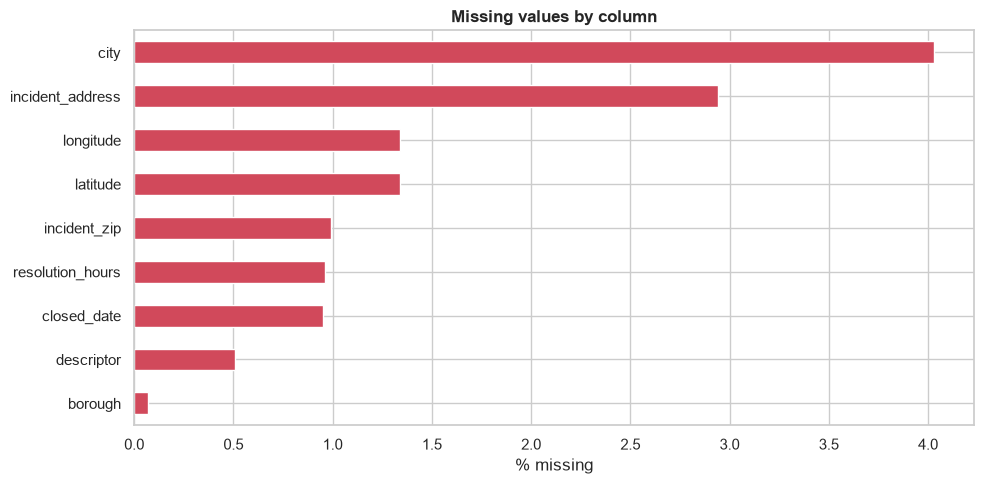

In [6]:
mt = missing_tbl[missing_tbl['missing'] > 0]
if not mt.empty:
    ax = mt['pct'].plot(kind='barh', color='#d1495b')
    ax.invert_yaxis()
    ax.set_xlabel('% missing')
    ax.set_title('Missing values by column')
    plt.tight_layout(); plt.show()
else:
    print('No missing values.')

## 3. Duplicate Analysis

`unique_key` is the natural primary key (already de-duplicated by the pipeline). We confirm here and also check for full-row duplicates.

In [7]:
dup_key = df['unique_key'].duplicated().sum()
dup_full = df.duplicated().sum()
print(f'Duplicate unique_key values : {dup_key}')
print(f'Fully duplicated rows       : {dup_full}')
print(f'Distinct unique_key values  : {df["unique_key"].nunique():,} / {len(df):,}')

Duplicate unique_key values : 0
Fully duplicated rows       : 0
Distinct unique_key values  : 50,000 / 50,000


## 4. Complaint Category Distribution

What citizens report most — the target space for the M1 NLP classifier.

Distinct complaint types: 150


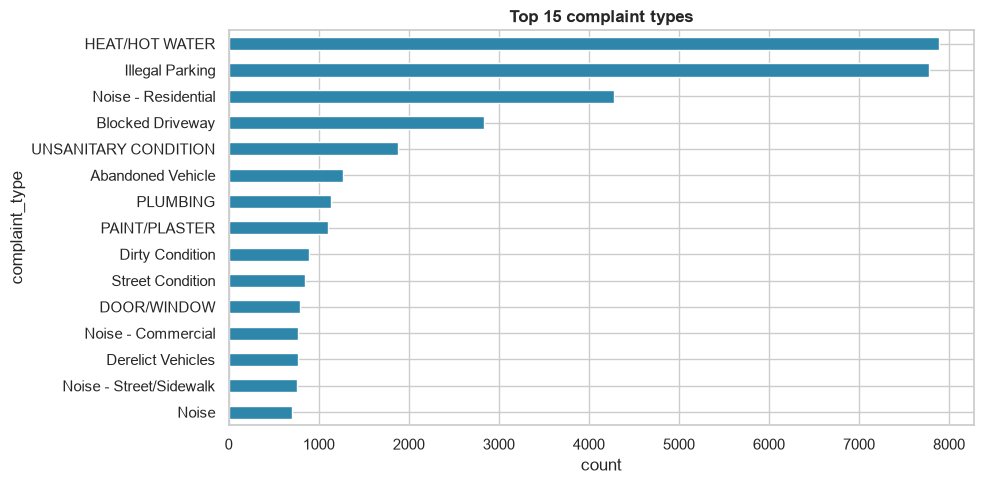

complaint_type
HEAT/HOT WATER             7883
Illegal Parking            7777
Noise - Residential        4280
Blocked Driveway           2838
UNSANITARY CONDITION       1879
Abandoned Vehicle          1267
PLUMBING                   1131
PAINT/PLASTER              1107
Dirty Condition             889
Street Condition            850
DOOR/WINDOW                 792
Noise - Commercial          775
Derelict Vehicles           768
Noise - Street/Sidewalk     761
Noise                       701
Name: count, dtype: int64[pyarrow]

In [8]:
print(f'Distinct complaint types: {df["complaint_type"].nunique()}')
top = df['complaint_type'].value_counts().head(15)
ax = top.sort_values().plot(kind='barh', color='#2e86ab')
ax.set_xlabel('count'); ax.set_title('Top 15 complaint types')
plt.tight_layout(); plt.show()
top

## 5. Borough Distribution

Geographic spread across the five boroughs.

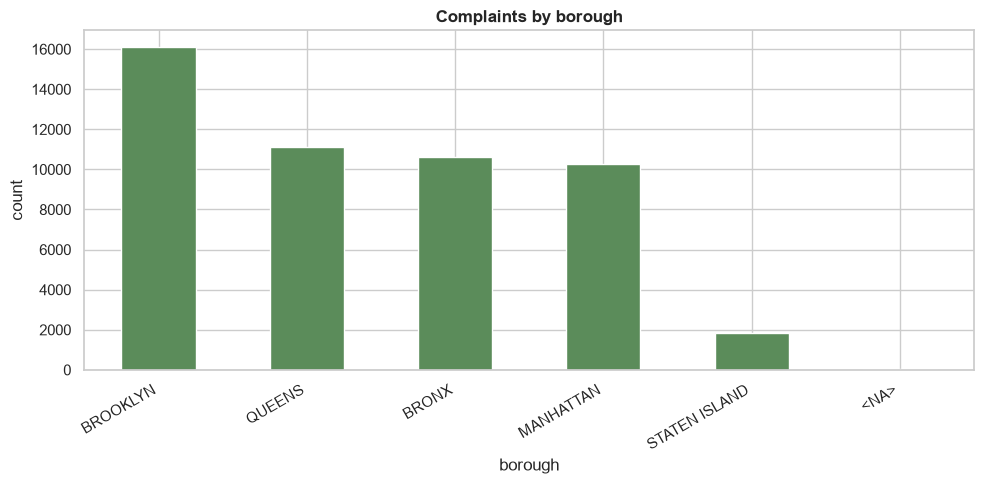

borough
BROOKLYN         32.25
QUEENS           22.26
BRONX            21.22
MANHATTAN        20.57
STATEN ISLAND     3.63
<NA>              0.07
Name: pct, dtype: double[pyarrow]

In [9]:
bc = df['borough'].value_counts(dropna=False)
ax = bc.plot(kind='bar', color='#5b8c5a')
ax.set_ylabel('count'); ax.set_title('Complaints by borough')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
(bc / len(df) * 100).round(2).rename('pct')

## 6. Time Distribution

Temporal patterns in `created_date`. (The bounded dev slice spans a short window, so we focus on intra-week / intra-day seasonality; longer history for forecasting arrives in M6.)

In [10]:
df['created_date'] = pd.to_datetime(df['created_date'])
df['hour'] = df['created_date'].dt.hour
df['dow'] = df['created_date'].dt.day_name()
df['date'] = df['created_date'].dt.date
print('Date range:', df['created_date'].min(), '->', df['created_date'].max())

Date range: 2024-01-01 00:00:00 -> 2024-01-06 13:53:47


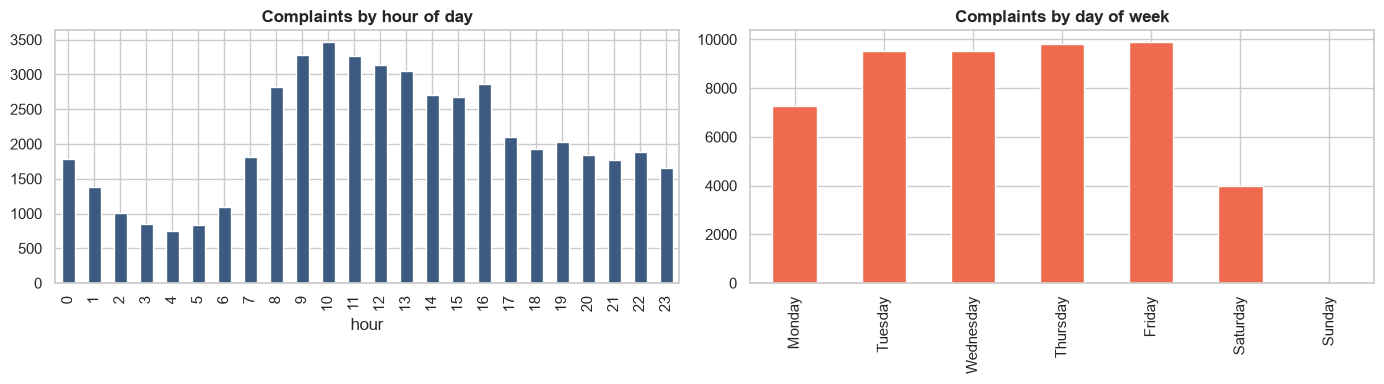

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#3d5a80')
axes[0].set_title('Complaints by hour of day'); axes[0].set_xlabel('hour')
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['dow'].value_counts().reindex(order).plot(kind='bar', ax=axes[1], color='#ee6c4d')
axes[1].set_title('Complaints by day of week'); axes[1].set_xlabel('')
plt.tight_layout(); plt.show()

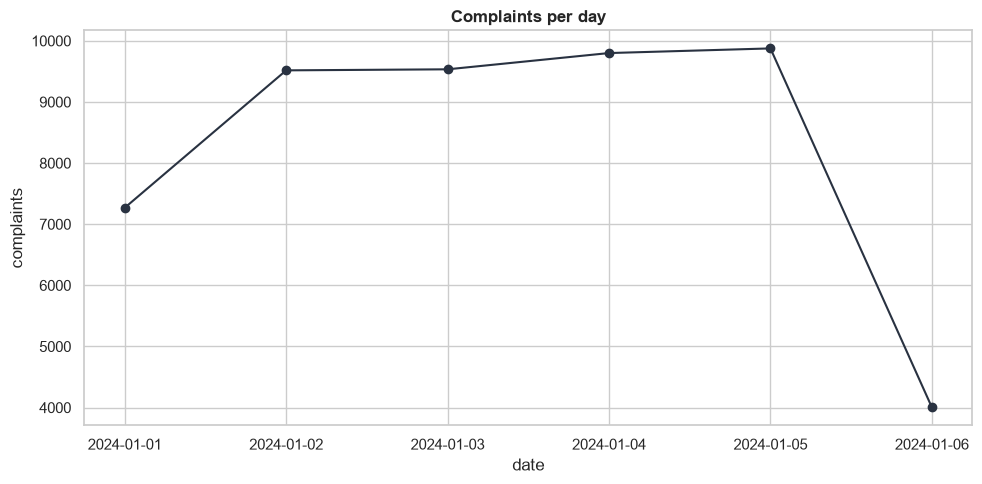

In [12]:
daily = df.groupby('date').size()
ax = daily.plot(marker='o', color='#293241')
ax.set_ylabel('complaints'); ax.set_title('Complaints per day')
plt.tight_layout(); plt.show()

## 7. Resolution Time Analysis

`resolution_hours` (closed complaints only) — the target for the M4 resolution-time regressor. The distribution is heavy-tailed, so we view it on a log scale.

In [13]:
res = df['resolution_hours'].dropna()
print(f'Closed complaints with resolution time: {len(res):,}')
res.describe().round(2)

Closed complaints with resolution time: 49,521


count    49521.00
mean       330.38
std       1245.20
min          0.00
25%          1.01
50%         13.89
75%         84.14
max      21180.56
Name: resolution_hours, dtype: float64

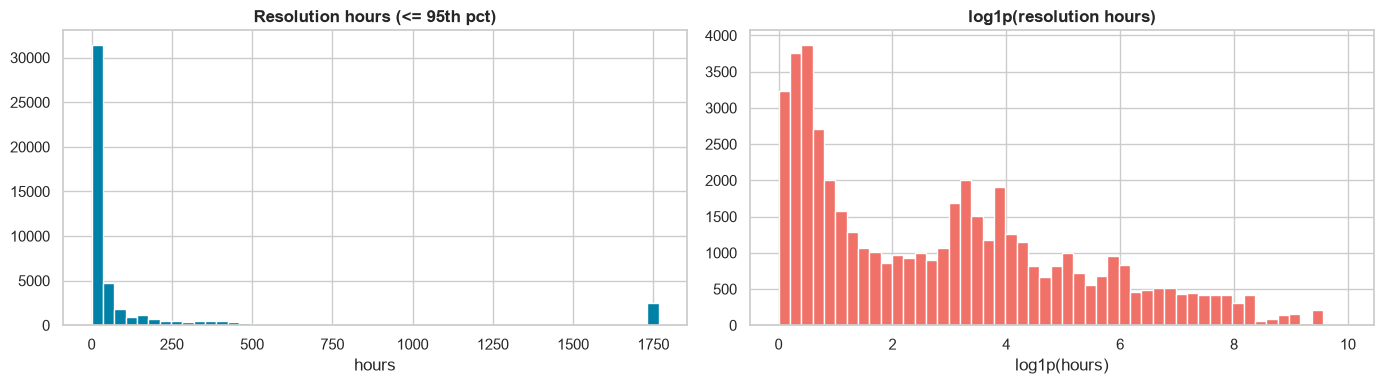

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(res.clip(upper=res.quantile(0.95)), bins=50, color='#0081a7')
axes[0].set_title('Resolution hours (<= 95th pct)'); axes[0].set_xlabel('hours')
axes[1].hist(np.log1p(res), bins=50, color='#f07167')
axes[1].set_title('log1p(resolution hours)'); axes[1].set_xlabel('log1p(hours)')
plt.tight_layout(); plt.show()

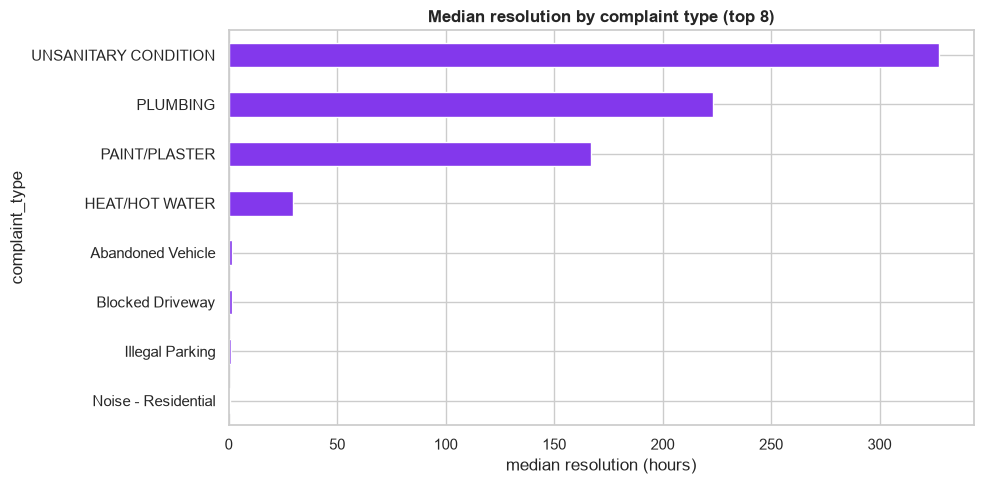

complaint_type
Noise - Residential       0.60
Illegal Parking           1.16
Blocked Driveway          1.58
Abandoned Vehicle         1.66
HEAT/HOT WATER           29.45
PAINT/PLASTER           167.03
PLUMBING                223.18
UNSANITARY CONDITION    327.19
Name: resolution_hours, dtype: float64

In [15]:
top_types = df['complaint_type'].value_counts().head(8).index
med = (df[df['complaint_type'].isin(top_types)]
       .groupby('complaint_type')['resolution_hours'].median().sort_values())
ax = med.plot(kind='barh', color='#8338ec')
ax.set_xlabel('median resolution (hours)'); ax.set_title('Median resolution by complaint type (top 8)')
plt.tight_layout(); plt.show()
med.round(2)

## 8. Geographic Distribution

Spatial spread of geocoded complaints (`geo_valid` points). These coordinates back the PostGIS geometry column and the M5 hotspot analysis.

Geocoded rows: 49,325


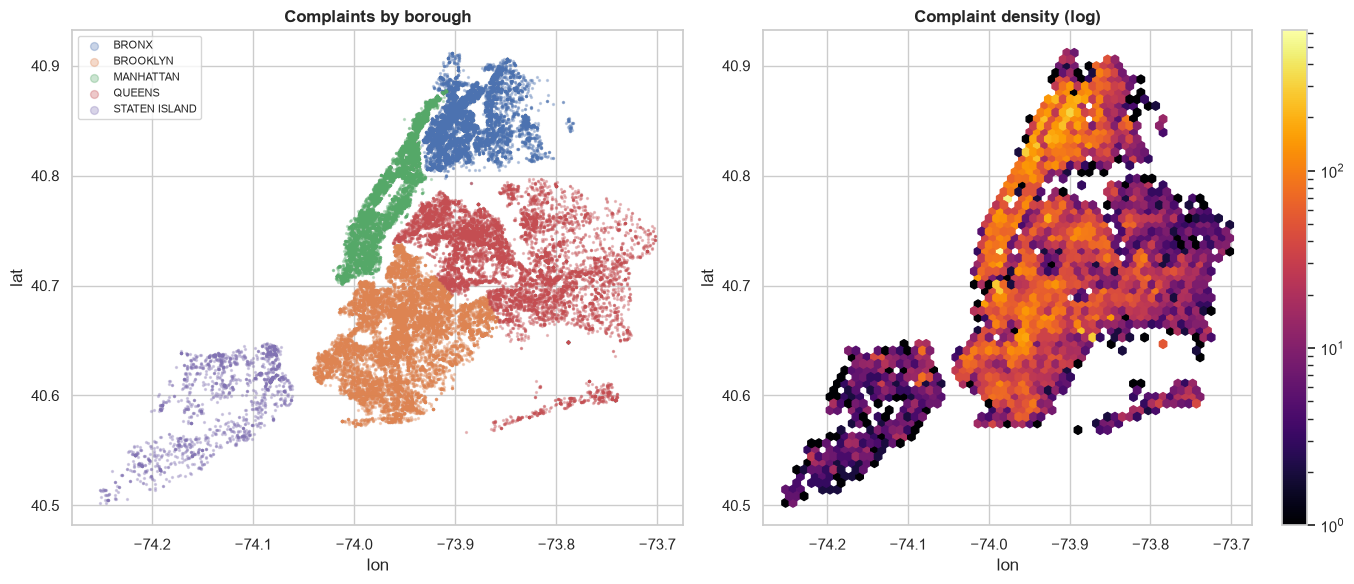

In [16]:
geo = df[df['geo_valid'] == True][['latitude', 'longitude', 'borough']].dropna()
print(f'Geocoded rows: {len(geo):,}')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for b, g in geo.groupby('borough'):
    axes[0].scatter(g['longitude'], g['latitude'], s=2, alpha=0.3, label=b)
axes[0].set_title('Complaints by borough'); axes[0].set_xlabel('lon'); axes[0].set_ylabel('lat')
axes[0].legend(markerscale=4, fontsize=8)
hb = axes[1].hexbin(geo['longitude'], geo['latitude'], gridsize=60, cmap='inferno', bins='log')
axes[1].set_title('Complaint density (log)'); axes[1].set_xlabel('lon'); axes[1].set_ylabel('lat')
fig.colorbar(hb, ax=axes[1])
plt.tight_layout(); plt.show()

## 9. Data Quality Summary

Key quality indicators for this development slice.

In [17]:
summary = {
    'total_rows': len(df),
    'distinct_complaint_types': int(df['complaint_type'].nunique()),
    'rows_missing_geo': int(df['latitude'].isna().sum()),
    'rows_geocoded': int((df['geo_valid'] == True).sum()),
    'rows_with_resolution': int(df['resolution_hours'].notna().sum()),
    'date_min': str(df['created_date'].min()),
    'date_max': str(df['created_date'].max()),
    'boroughs': int(df['borough'].nunique()),
}
pd.Series(summary)

total_rows                                50000
distinct_complaint_types                    150
rows_missing_geo                            670
rows_geocoded                             49330
rows_with_resolution                      49521
date_min                    2024-01-01 00:00:00
date_max                    2024-01-06 13:53:47
boroughs                                      5
dtype: object

## 10. Initial Feature Engineering Ideas

Grounded in the patterns above and mapped to the model roadmap in `docs/BLUEPRINT.md`:

**Temporal** (cheap, high-signal for M4 regression & M6 forecasting)
- `hour`, `day_of_week`, `is_weekend`, `month`, `is_holiday`
- Lag / rolling-count features per category & borough (M6)

**Text** (M1 NLP classifier, M3 embeddings)
- TF-IDF / transformer embeddings of `complaint_type` + `descriptor`
- Text length, keyword flags (urgency terms)

**Geospatial** (M5 hotspots / clustering)
- `borough`, `incident_zip` as categoricals
- Spatial density / nearest-hotspot distance from the PostGIS `geom`

**Categorical / operational**
- `agency`, `agency_name` (routing signal)
- `status` lifecycle features

**Target transforms** (M4)
- `log1p(resolution_hours)` to tame the heavy tail (seen in §7)
- Duplicate / near-duplicate flags via embedding similarity + spatial-temporal blocking (M3)

## 11. Summary Statistics

Numeric and categorical summaries to close the analysis.

In [18]:
df[['resolution_hours', 'latitude', 'longitude', 'hour']].describe().round(3)

,resolution_hours,latitude,longitude,hour
count,49521.000,49330.000,49330.000,50000.000
mean,330.382,40.737,-73.924,12.376
std,1245.204,0.086,0.073,6.015
min,0.000,40.502,-74.251,0.000
25%,1.010,40.670,-73.969,9.000
50%,13.890,40.731,-73.927,12.000
75%,84.139,40.819,-73.883,17.000
max,21180.564,40.912,-73.702,23.000


In [19]:
df[['complaint_type', 'borough', 'agency', 'status']].describe(include='all')

,complaint_type,borough,agency,status
count,50000,49963,50000,50000
unique,150,5,14,7
top,HEAT/HOT WATER,BROOKLYN,NYPD,Closed
freq,7883,16125,20027,49690


---
### Conclusion

The silver dataset is clean, well-typed, geocoded, and loaded into PostGIS/pgvector-ready Postgres. Category, borough, temporal, resolution, and spatial distributions are all sensible and ready to support modeling from **M1** onward. No modeling is performed here (M0 scope).